In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import os
import pynbody
import pynbody.plot.sph as sph
from IPython.display import clear_output, display

from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d


SMALLSIZE = 12
NORMALSIZE = 12
LARGESIZE = 12

params = {
    "font.family":"serif",
    "mathtext.fontset":"stix",
    "font.size": SMALLSIZE,
    "axes.titlesize" : SMALLSIZE,
    "axes.labelsize" : NORMALSIZE,
    'xtick.labelsize': SMALLSIZE,
    'ytick.labelsize': SMALLSIZE,      
    'legend.fontsize': SMALLSIZE,  
    'figure.titlesize': LARGESIZE,
    'pgf.texsystem' : "pdflatex"
}
matplotlib.rcParams.update(params)

isob_dir = "../data/IsoB_dt10_all"
snap_names = [f"GLX.000{10*(j):03.0f}" for j in range(1, 62)] + [f"GLX.0{10*j:04.0f}" for j in range(62, 101)]


In [3]:
pq_names = [f"GLX.00{10*(j):04.0f}.parquet" for j in range(1, 101)]
pq_path = "../data/stars/"

print(pq_names)

['GLX.000010.parquet', 'GLX.000020.parquet', 'GLX.000030.parquet', 'GLX.000040.parquet', 'GLX.000050.parquet', 'GLX.000060.parquet', 'GLX.000070.parquet', 'GLX.000080.parquet', 'GLX.000090.parquet', 'GLX.000100.parquet', 'GLX.000110.parquet', 'GLX.000120.parquet', 'GLX.000130.parquet', 'GLX.000140.parquet', 'GLX.000150.parquet', 'GLX.000160.parquet', 'GLX.000170.parquet', 'GLX.000180.parquet', 'GLX.000190.parquet', 'GLX.000200.parquet', 'GLX.000210.parquet', 'GLX.000220.parquet', 'GLX.000230.parquet', 'GLX.000240.parquet', 'GLX.000250.parquet', 'GLX.000260.parquet', 'GLX.000270.parquet', 'GLX.000280.parquet', 'GLX.000290.parquet', 'GLX.000300.parquet', 'GLX.000310.parquet', 'GLX.000320.parquet', 'GLX.000330.parquet', 'GLX.000340.parquet', 'GLX.000350.parquet', 'GLX.000360.parquet', 'GLX.000370.parquet', 'GLX.000380.parquet', 'GLX.000390.parquet', 'GLX.000400.parquet', 'GLX.000410.parquet', 'GLX.000420.parquet', 'GLX.000430.parquet', 'GLX.000440.parquet', 'GLX.000450.parquet', 'GLX.0004

../data/IsoB_dt10_all/GLX.01000
['vel', '', 'pos', 'MassHot', 'HeI', 'OxMassFrac', 'uHot', 'Tinc', 'HI', 'FeMassFrac', 'metals', 'tform', 'tempEff', 'mass', 'uDotFB', 'u', 'eps', 'HeII', 'iord', 'massform', 'igasorder', 'massHot', 'phi', 'timeform']


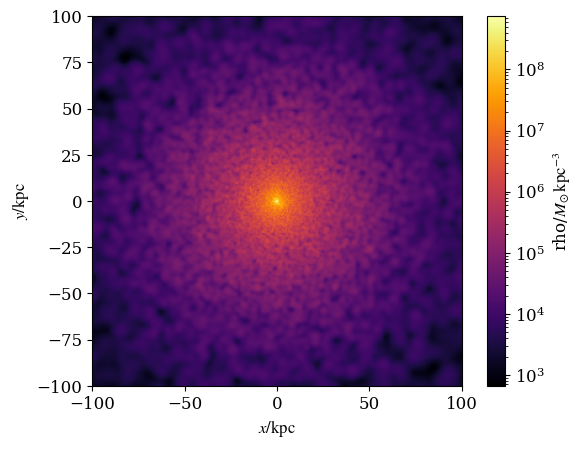

In [83]:
# for i, pq in enumerate(pq_names[::5]):
#     df = pd.read_parquet(pq_path + pq)
    
snap = snap_names[99]
print(f"{isob_dir}/{snap}")
sim = pynbody.load(f"{isob_dir}/{snap}")
print(sim.s.loadable_keys())
#pynbody.gravity.all_pm(sim)
pots = sim['phi']
x = sim['x']
y = sim['y']


pynbody.plot.image(sim.dm, 'rho', '200 kpc', 300, norm='log', units='Msol kpc**-3', cmap='inferno') # , vmin=10e-23, vmax=10e-20)

# pynbody.analysis.angmom.faceon(sim)
